In [1]:
import os, sys
import pickle
import numpy as np
import pathlib
from typing import Dict, List, Optional, Tuple
import warnings
import alchemlyb
sys.path.append('/dfs9/dmobley-lab/swapnilw/waterNES/')
sys.path.append('/dfs9/dmobley-lab/swapnilw/openeye_colab/analysis_tool_rbfe')
from water_nes.analysis.free_energy_estimate import FreeEnergyEstimate
from water_nes.analysis.nes_free_energy import calculate_nes_free_energy
from alchemlyb.estimators import MBAR
from alchemlyb.parsing.gmx import extract_u_nk
from alchemlyb.postprocessors.units import get_unit_converter
from alchemlyb.preprocessing import slicing, statistical_inefficiency
from alchemlyb.visualisation import plot_mbar_overlap_matrix
from MDAnalysis import transformations as mda_transformations
from MDAnalysis.analysis import distances as mda_distances
from pymbar.timeseries import ParameterError
from utils import get_water_restraint_force_constant
import matplotlib.pyplot as plt
from alchemlyb.preprocessing.subsampling import decorrelate_u_nk

/data/homezvol1/swapnilw/.conda/envs/simple_py37env/lib/python3.7/site-packages/MDAnalysis/coordinates/chemfiles.py:59: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  MIN_CHEMFILES_VERSION = LooseVersion("0.9")


In [2]:
from glob import glob 
root_path = "/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c"
for xvg in glob(root_path+"/lambda_*/Production_MD/prod.xvg"):
    #try:
    print(xvg)
    data = np.loadtxt(xvg, comments=["#", "@"])[:, 0]
    #except ValueError:
    #    print(xvg)
    uniques, counts = np.unique(data, return_counts=True)
    duplicates = uniques[counts > 1]
    if len(duplicates) > 0:
        print(xvg, duplicates)

/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_15/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_10/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_18/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_19/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_2/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_11/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_14/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_16/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_5/Production_MD/prod.xvg
/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c/lambda_17/Production_MD/prod.xvg


ValueError: Wrong number of columns at line 46499

In [8]:
cycle_directory="/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c"
subsample = True
conservative = True
u_nk_all_stages = []
file_name = "prod.xvg"
for stage in range(0, 20):
    with warnings.catch_warnings():
                # Tons of pandas warnings here
        warnings.simplefilter(action="ignore", category=FutureWarning)
        full_u_nk = extract_u_nk(
            f"{cycle_directory}/lambda_{stage}/Production_MD/{file_name}", T=298.15
        )
        u_nk = slicing(full_u_nk, step=1)
        if subsample:
            u_nk_all_stages.append(
                statistical_inefficiency(
                    u_nk,
                    series=u_nk[u_nk.columns[stage]],
                    conservative=conservative,
                )
            )
        else:
            u_nk_all_stages.append(u_nk)



decorrelated_u_nk_list = [decorrelate_u_nk(u_nk) for u_nk in u_nk_all_stages]
#decorrelated_u_nk_list[0]
mbar=MBAR().fit(alchemlyb.concat(decorrelated_u_nk_list))

KeyError: "Duplicate time values found; it's generally advised to use slicing on DataFrames with unique time values for each row. Use `force=True` to ignore this error."

In [21]:
cycle_directory="/dfs9/dmobley-lab/swapnilw/pdgfra_project/active/fe_calcs/wt_y849c"
subsample = False
conservative = False
u_nk_all_stages = []
file_name = "prod.xvg"
for stage in range(0, 20):
    with warnings.catch_warnings():
                # Tons of pandas warnings here
        warnings.simplefilter(action="ignore", category=FutureWarning)
        full_u_nk = extract_u_nk(
            f"{cycle_directory}/lambda_{stage}/Production_MD/{file_name}", T=298.15
        )
        #u_nk = slicing(full_u_nk, step=1)
        if subsample:
            u_nk_all_stages.append(
                statistical_inefficiency(
                    full_u_nk,
                    series=full_u_nk[full_u_nk.columns[stage]],
                    conservative=conservative,
                )
            )
        else:
            u_nk_all_stages.append(full_u_nk)



decorrelated_u_nk_list = [decorrelate_u_nk(full_u_nk) for full_u_nk in u_nk_all_stages]
#decorrelated_u_nk_list[0]
mbar=MBAR().fit(alchemlyb.concat(decorrelated_u_nk_list))

/data/homezvol1/swapnilw/.conda/envs/simple_py37env/lib/python3.7/site-packages/alchemlyb/preprocessing/subsampling.py:135: FutureWarning: In a future version of pandas all arguments of DataFrame.sort_index will be keyword-only
  return df.sort_index(0).reset_index('time').duplicated('time').any()
/data/homezvol1/swapnilw/.conda/envs/simple_py37env/lib/python3.7/site-packages/alchemlyb/preprocessing/subsampling.py:133: FutureWarning: In a future version of pandas all arguments of Series.sort_index will be keyword-only
  return df.sort_index(0).reset_index('time', name='').duplicated('time').any()


In [22]:

#mbar=MBAR().fit(alchemlyb.concat(u_nk_all_stages))
mbar.delta_f_

,0.00,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00
0.00,0.000000,1.662516,1.771940,1.950963,2.406288,3.129376,4.086844,5.158467,6.059807,7.167105,10.910743,13.161154,15.671232,18.593102,21.741379,25.042159,28.607857,32.436731,36.460312,40.479124
0.05,-1.662516,0.000000,0.109424,0.288446,0.743772,1.466860,2.424328,3.495951,4.397291,5.504589,9.248227,11.498638,14.008716,16.930586,20.078863,23.379643,26.945341,30.774215,34.797796,38.816608
0.10,-1.771940,-0.109424,0.000000,0.179022,0.634347,1.357436,2.314903,3.386526,4.287866,5.395165,9.138803,11.389213,13.899291,16.821161,19.969439,23.270218,26.835916,30.664791,34.688371,38.707183
0.15,-1.950963,-0.288446,-0.179022,0.000000,0.455325,1.178413,2.135881,3.207504,4.108844,5.216143,8.959781,11.210191,13.720269,16.642139,19.790416,23.091196,26.656894,30.485768,34.509349,38.528161
0.20,-2.406288,-0.743772,-0.634347,-0.455325,0.000000,0.723088,1.680556,2.752179,3.653519,4.760817,8.504456,10.754866,13.264944,16.186814,19.335091,22.635871,26.201569,30.030443,34.054024,38.072836
0.25,-3.129376,-1.466860,-1.357436,-1.178413,-0.723088,0.000000,0.957468,2.029091,2.930431,4.037729,7.781367,10.031778,12.541856,15.463726,18.612003,21.912783,25.478481,29.307355,33.330936,37.349748
0.30,-4.086844,-2.424328,-2.314903,-2.135881,-1.680556,-0.957468,0.000000,1.071623,1.972963,3.080261,6.823900,9.074310,11.584388,14.506258,17.654535,20.955315,24.521013,28.349887,32.373468,36.392280
0.35,-5.158467,-3.495951,-3.386526,-3.207504,-2.752179,-2.029091,-1.071623,0.000000,0.901340,2.008638,5.752277,8.002687,10.512765,13.434635,16.582912,19.883692,23.449390,27.278264,31.301845,35.320657
0.40,-6.059807,-4.397291,-4.287866,-4.108844,-3.653519,-2.930431,-1.972963,-0.901340,0.000000,1.107298,4.850937,7.101347,9.611425,12.533295,15.681572,18.982352,22.548050,26.376924,30.400505,34.419317
0.45,-7.167105,-5.504589,-5.395165,-5.216143,-4.760817,-4.037729,-3.080261,-2.008638,-1.107298,0.000000,3.743638,5.994049,8.504127,11.425997,14.574274,17.875054,21.440752,25.269626,29.293207,33.312019


In [23]:
mbar.delta_f_.iloc[1][0]

-1.6625160451944279

<AxesSubplot:>

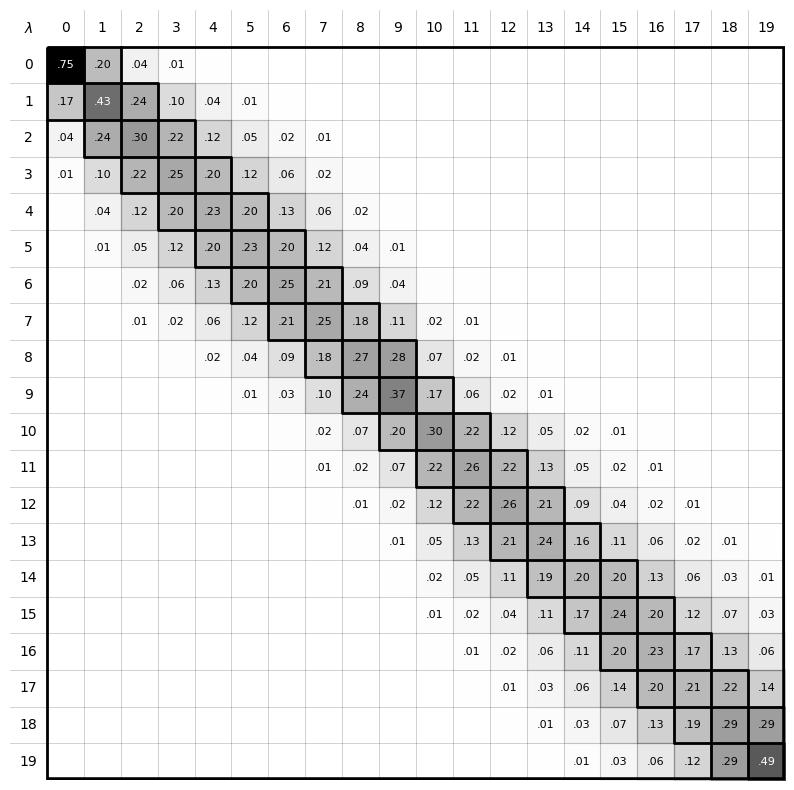

In [24]:
plot_mbar_overlap_matrix(mbar.overlap_matrix)

In [25]:
mbar.delta_f_.keys()

Float64Index([ 0.0, 0.05,  0.1, 0.15,  0.2, 0.25,  0.3, 0.35,  0.4, 0.45, 0.55,
               0.6, 0.65,  0.7, 0.75,  0.8, 0.85,  0.9, 0.95,  1.0],
             dtype='float64')

In [66]:
from alchemlyb.postprocessors.units import to_kcalmol, to_kJmol, to_kT
df=to_kcalmol(mbar.delta_f_)
FE = df.loc[0.00,0.01] + df.loc[0.01,0.025]+ df.loc[0.025,0.05]+ df.loc[0.05,0.1]+ df.loc[0.1,0.2]+\
df.loc[0.2,0.3]+ df.loc[0.3,0.4]+ df.loc[0.4,0.5]+ df.loc[0.5,0.6]+ df.loc[0.6,0.7]+\
df.loc[0.7,0.8]+ df.loc[0.8,0.9]+ df.loc[0.9,0.95]+ df.loc[0.95,0.975]+ df.loc[0.975,1.0]
FE

-23.330494884389246

In [67]:
from alchemlyb.postprocessors.units import to_kcalmol, to_kJmol, to_kT
df=to_kcalmol(mbar.d_delta_f_)
FE = df.loc[0.00,0.01] + df.loc[0.01,0.025]+ df.loc[0.025,0.05]+ df.loc[0.05,0.1]+ df.loc[0.1,0.2]+\
df.loc[0.2,0.3]+ df.loc[0.3,0.4]+ df.loc[0.4,0.5]+ df.loc[0.5,0.6]+ df.loc[0.6,0.7]+\
df.loc[0.7,0.8]+ df.loc[0.8,0.9]+ df.loc[0.9,0.95]+ df.loc[0.95,0.975]+ df.loc[0.975,1.0]
FE

0.42364968514140366

In [99]:
df_error=to_kcalmol(mbar.d_delta_f_)
error = df_error.loc[0.00,0.05] + df_error.loc[0.05,0.10]+ df_error.loc[0.10,0.15]+ df_error.loc[0.15,0.20]+ df_error.loc[0.20,0.25]+\
df_error.loc[0.25,0.30]+ df_error.loc[0.30,0.35]+ df_error.loc[0.35,0.40]+ df_error.loc[0.40,0.45]+ df_error.loc[0.45,0.55]+\
df_error.loc[0.55,0.60]+ df_error.loc[0.60,0.65]+ df_error.loc[0.65,0.70]+ df_error.loc[0.70,0.75]+\
+ df_error.loc[0.75,0.80]+ df_error.loc[0.80,0.85]+ df_error.loc[0.85,0.90]+ df_error.loc[0.90,0.95]+ df_error.loc[0.95,1.00]
error

0.11761559433955411

In [11]:
D842V
dG_active = -23.33 +- 0.4 kcal/mole
dG_inactive = -19.24 +- 0.4 kcal/mole

Y849C
dG_active = 25.167 +- 0.04 kcal/mole
dG_inactive = 26.927 +- 0.1 kcal/mole

SyntaxError: invalid syntax (3796450916.py, line 1)

In [26]:
output_units = "kcal/mol"
energy = sum(
            [
                get_unit_converter(output_units)(mbar.delta_f_).iloc[idx-1][idx]
                for idx in range(1, mbar.delta_f_.shape[0])
            ]
        )
energy

KeyError: 2

In [35]:
error = sum(
            [
                get_unit_converter(output_units)(mbar.d_delta_f_).iloc[idx-1][idx]
                for idx in range(1, mbar.d_delta_f_.shape[0])
            ]
        )
error

0.18560456600017783